In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

s25_firstHalf = s25[s25['GAME_DATE'] < '2025-01-15']
s25_secondHalf = s25[s25['GAME_DATE'] >= '2025-01-15']

train_df = pd.concat([s19,s20,s21,s22,s23,s24, s25, s26])
# val_df = s25
# test_df = s26

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
# print(f"Validation data shape: {val_df.shape}")
# print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
# print(f"Test data shape: {test_df.shape}")
# print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
# test_df.tail()

Training data shape: (176916, 783)
Training date range: 2018-10-17 to 2025-10-25


In [3]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    
    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',
    'MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE',
    'PTS_ROLLING_AVG_25',
    'PTS_PER_MIN_X_USG',
    'PTS_LAG_2',
    'PTS_VOLATILITY_25_TO_DATE',
    'PTS_EXTREME_VOLATILITY',
    'PTS_RECENT_HIGH_VOLATILITY',
    'FGA_LAG_1',
    'FGA_VOLATILITY_10_TO_DATE',
    'MATCHUP_AVG_FGA_LAST_3_TO_DATE',
    'FTA_ROLLING_AVG_40',
    'FT_RATE_ROLLING_AVG_5',
    '3PA_SHARE',
    'USG_PCT_LAG_1',
    'USG_PCT_ROLLING_AVG_25',
    'USG_PCT_VOLATILITY_5_TO_DATE',
    'TS_PCT_ROLLING_AVG_25',
    'TS_PCT_VOLATILITY_10_TO_DATE',
    'PIE_AVG_TO_DATE',
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10',
    'FG_PCT_AVG_TO_DATE',
    'PF_ROLLING_AVG_5',

    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_PTS_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_3',

    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'OPP_GUARD_DEF_FG_PCT_ALLOWED',
    'OPP_GUARD_DEF_3PT_PCT_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'OPP_FORWARD_DEF_RATING',
    'OPP_FORWARD_DEF_FG_PCT_ALLOWED',
    'OPP_FORWARD_DEF_3PT_PCT_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'OPP_CENTER_DEF_RATING',
    'OPP_CENTER_DEF_FG_PCT_ALLOWED',
    'OPP_CENTER_DEF_3PT_PCT_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'PTS_PER_MIN_X_OPP_DEF_RATING',

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_AWAY_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_AWAY_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_AWAY_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PLAYER_AWAY_FTA_DELTA',
    'MATCHUP_PTS_DELTA_LAST_3',
    'MATCHUP_FGA_DELTA_LAST_3',
    'MATCHUP_USG_PCT_DELTA_LAST_3',
    'MATCHUP_EFG_PCT_DELTA_LAST_3'
 ]

In [59]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('CENTER')
# features = columns[guardIDX + 1:]
# newFeatures = features

In [60]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=50,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

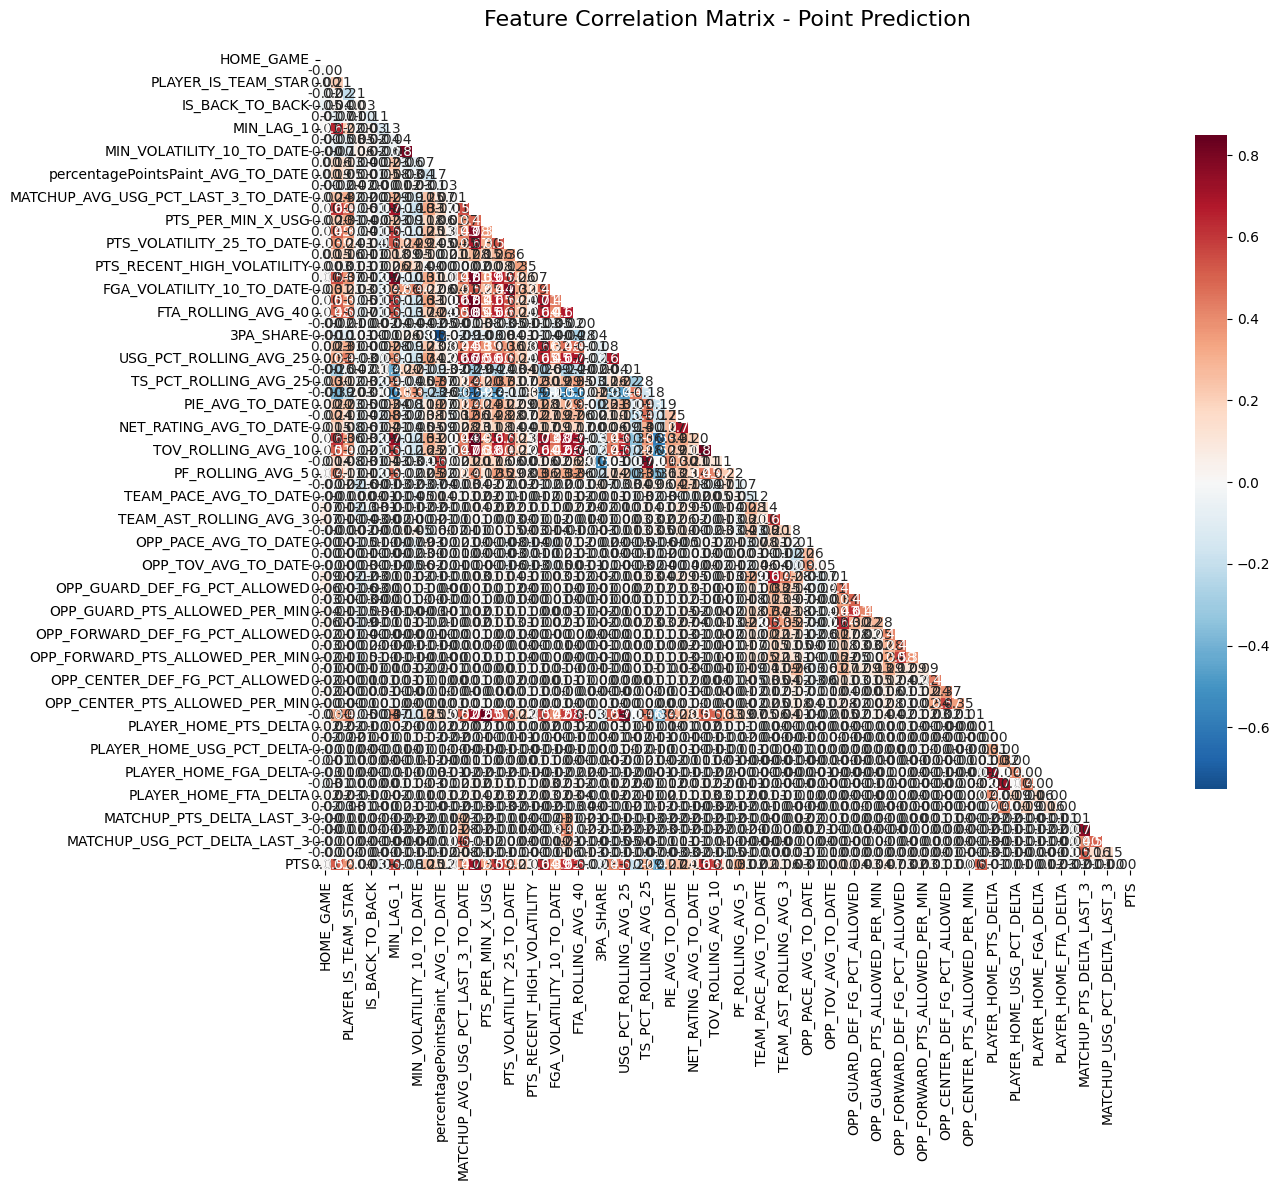

TOP 10 FEATURES MOST CORRELATED WITH PTS:
 1. PTS_ROLLING_AVG_25             0.720
 2. FGA_LAG_1                      0.637
 3. TCHS_ROLLING_AVG_10            0.629
 4. FTA_ROLLING_AVG_40             0.622
 5. MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.617
 6. PTS_LAG_2                      0.587
 7. TOV_ROLLING_AVG_10             0.577
 8. USG_PCT_ROLLING_AVG_25         0.565
 9. MIN_LAG_1                      0.562
10. STARTING                       0.515

SUMMARY:
Original features: 70
Removed features: 0
Final features: 70


In [48]:
corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

top_features = remove_highly_correlated_features(train_df, top_features, threshold=0.85)

### Train xgboost model and also using quantile regression

In [ ]:
xgbModels, val_metrics = fit_quantile_models(
    train_df, None, 
    top_features, 
    'PTS', 
    'GAME_DATE', 
    'PLAYER_ID',
    recent_n=12, recent_weight=2.5, use_gpu=False, 
    tune_hyperparams=False, tune_iters=50)

# Make predictions with quantile models
# pred_df = predict_quantiles(xgbModels, test_df, top_features)

# Evaluate quantile models on test set
# test_results = evaluate_quantile_models(xgbModels, test_df, top_features, 'PTS')

# print("=" * 50)
# print("QUANTILE REGRESSION VALIDATION RESULTS")
# for quantile_name, results in val_metrics.items():
#     print(f"{quantile_name} Val RMSE: {results['RMSE']:.3f}")
#     print(f"{quantile_name} Val MAE: {results['MAE']:.3f}")
#     print(f"{quantile_name} Val R²: {results['R2']:.3f}")

# print("\n" + "=" * 50)
# print("QUANTILE REGRESSION TEST RESULTS")
# for quantile_name, results in test_results.items():
#     print(f"{quantile_name} Test RMSE: {results['RMSE']:.3f}")
#     print(f"{quantile_name} Test MAE: {results['MAE']:.3f}")
#     print(f"{quantile_name} Test R²: {results['R2']:.3f}")

No validation data provided - using training data for early stopping

Training quantile model for q10...


KeyboardInterrupt: 

In [7]:
xgbModels

{'q10': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='quantile',
              feature_types=None, feature_weights=None, gamma=1.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
              max_depth=6, max_leaves=None, min_child_weight=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=-1, num_parallel_tree=None, ...),
 'q50': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6460723242676091, device=None,
              early_stopping_rounds=N

### Evaluate pinball loss on out-of-time data

In [45]:
validate_by_position_pinball_loss(xgbModels, test_df, top_features, 'PTS')

PINBALL LOSS BY POSITION

GUARD (n=487):
  q10: 1.4399
  q50: 2.6634
  q90: 1.5307

FORWARD (n=400):
  q10: 1.5783
  q50: 2.7505
  q90: 1.5989

CENTER (n=129):
  q10: 1.5746
  q50: 2.7078
  q90: 1.5994


### Plot SHAP values per position to verify the model leans on the right drivers


Q10 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_25             1.7654
  STARTING                       0.9394
  FGA_LAG_1                      0.2625
  MIN_LAG_1                      0.2428
  TEAM_PTS_ROLLING_AVG_3         0.1689
  TCHS_ROLLING_AVG_10            0.1583
  OPP_GUARD_DEF_RATING           0.1443
  PTS_LAG_2                      0.1190
  FTA_ROLLING_AVG_40             0.1126
  PTS_PER_MIN_X_USG              0.1095
  PTS_PER_MIN_X_OPP_DEF_RATING   0.0905
  USG_PCT_ROLLING_AVG_25         0.0684
  PLAYER_IS_TEAM_STAR            0.0658
  OPP_FORWARD_DEF_RATING         0.0532
  3PA_SHARE                      0.0512

By Position:
  GUARD (n=7034): PTS_ROLLING_AVG_25 (1.899)
  FORWARD (n=5284): PTS_ROLLING_AVG_25 (1.655)
  CENTER (n=1366): PTS_ROLLING_AVG_25 (1.502)


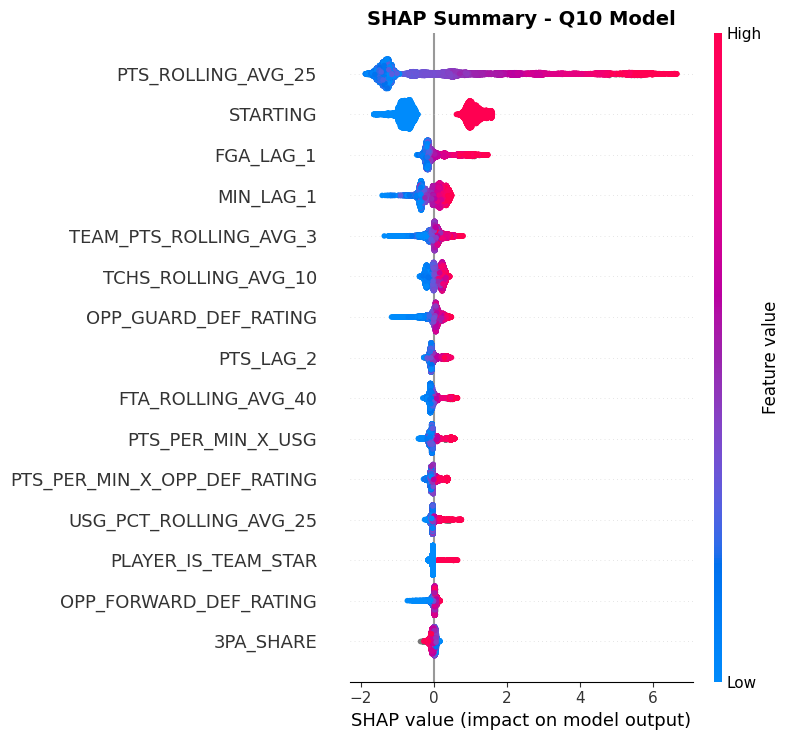


Q50 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_25             2.7429
  STARTING                       1.3937
  MIN_LAG_1                      0.4292
  FGA_LAG_1                      0.3722
  STAR_SAT_OUT                   0.3468
  TEAM_PTS_ROLLING_AVG_3         0.3334
  USG_PCT_ROLLING_AVG_25         0.2553
  PTS_PER_MIN_X_USG              0.2465
  OPP_GUARD_DEF_RATING           0.2377
  MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.2180
  TCHS_ROLLING_AVG_10            0.1917
  PTS_LAG_2                      0.1705
  PTS_DELTA_STAR_OUT             0.1464
  PTS_PER_MIN_X_OPP_DEF_RATING   0.1430
  TEAM_AST_ROLLING_AVG_3         0.1118

By Position:
  GUARD (n=7034): PTS_ROLLING_AVG_25 (2.918)
  FORWARD (n=5284): PTS_ROLLING_AVG_25 (2.594)
  CENTER (n=1366): PTS_ROLLING_AVG_25 (2.420)


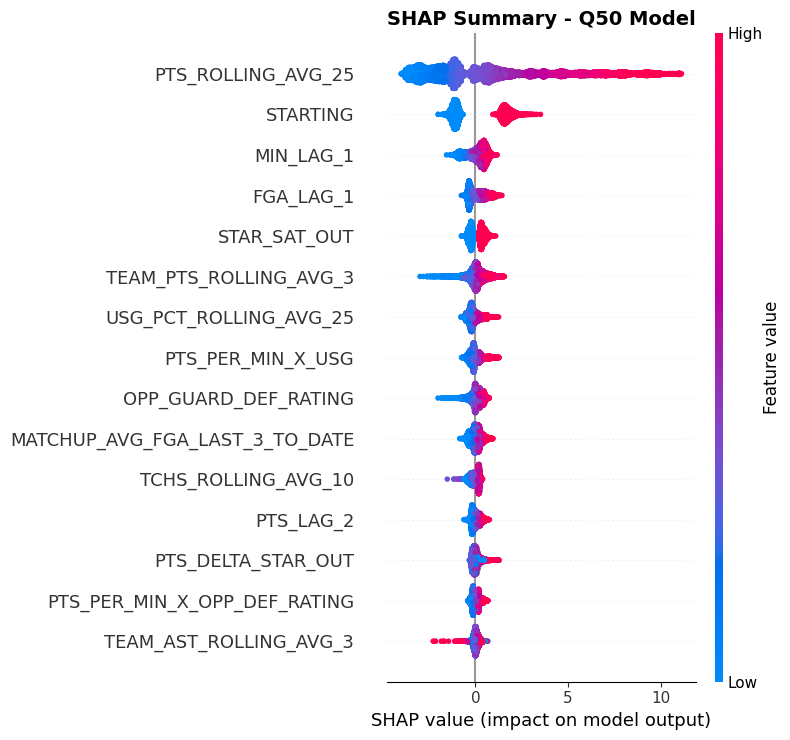


Q90 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_25             3.4084
  STARTING                       1.4700
  FGA_LAG_1                      0.9199
  TEAM_PTS_ROLLING_AVG_3         0.5926
  STAR_SAT_OUT                   0.5732
  MIN_LAG_1                      0.3349
  USG_PCT_ROLLING_AVG_25         0.3279
  OPP_GUARD_DEF_RATING           0.2985
  MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.2654
  PTS_PER_MIN_X_USG              0.2604
  PTS_VOLATILITY_25_TO_DATE      0.2559
  PTS_LAG_2                      0.2393
  PTS_DELTA_STAR_OUT             0.2086
  FG_PCT_AVG_TO_DATE             0.1316
  PLAYER_DAYS_REST               0.1265

By Position:
  GUARD (n=7034): PTS_ROLLING_AVG_25 (3.584)
  FORWARD (n=5284): PTS_ROLLING_AVG_25 (3.291)
  CENTER (n=1366): PTS_ROLLING_AVG_25 (2.957)


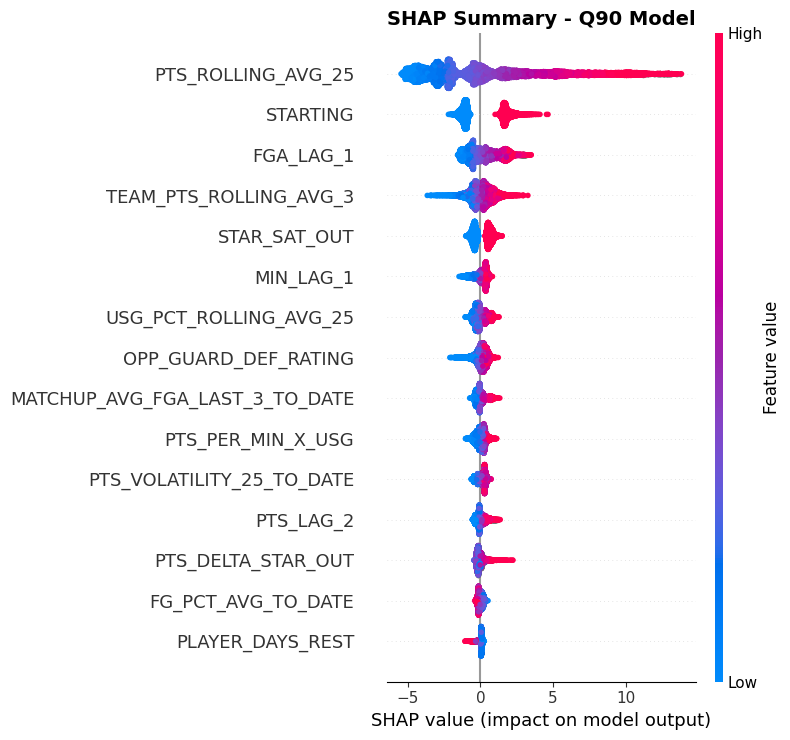

{'q10': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='quantile',
              feature_types=None, feature_weights=None, gamma=1.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
              max_depth=6, max_leaves=None, min_child_weight=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1072,
              n_jobs=-1, num_parallel_tree=None, ...),
 'q50': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6460723242676091, device=None,
              early_stopping_rounds=N

In [24]:
analyze_quantile_shap(xgbModels, test_df, top_features, 'PTS')

### Check top 20 highest residuals

In [35]:
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')
residuals_df.sort_values('residual_q50', ascending=False).head(10)

,actual,pred_q10,pred_q50,pred_q90,residual_q10,residual_q50,residual_q90,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN,GUARD,FORWARD,CENTER,interval_width,within_80_interval,within_50_interval
206,50,13.402615,16.721779,38.161427,36.597385,33.278221,11.838573,Aaron Gordon,DEN @ GSW,131,137.0,1,38.65,0,1,0,24.758812,False,False
407,41,12.697337,14.880502,34.800549,28.302663,26.119498,6.199451,Anthony Edwards,MIN @ POR,118,114.0,1,39.25,1,0,0,22.103210,False,False
207,50,16.002333,25.511229,39.088852,33.997667,24.488771,10.911148,Aaron Gordon,DEN @ GSW,131,137.0,1,38.65,0,1,0,23.086519,False,False
786,55,17.400421,31.039448,47.618984,37.599579,23.960552,7.381016,Shai Gilgeous-Alexander,OKC @ IND,141,135.0,1,45.35,1,0,0,30.218563,False,False
787,55,18.342695,31.446764,48.961483,36.657305,23.553236,6.038517,Shai Gilgeous-Alexander,OKC @ IND,141,135.0,1,45.35,1,0,0,30.618788,False,False
604,40,13.624131,16.703588,37.607464,26.375869,23.296412,2.392536,Tyrese Maxey,PHI @ BOS,117,116.0,1,41.40,1,0,0,23.983334,False,False
754,40,14.055068,17.232012,38.722336,25.944932,22.767988,1.277664,Victor Wembanyama,SAS @ DAL,125,92.0,1,29.68,0,1,0,24.667267,False,False
477,25,-0.010954,3.664682,10.499275,25.010954,21.335318,14.500725,Ziaire Williams,BKN vs. CLE,124,131.0,0,27.45,0,1,0,10.510229,False,False
381,37,13.623573,16.555519,38.740742,23.376427,20.444481,-1.740742,Giannis Antetokounmpo,MIL vs. WAS,133,120.0,1,26.75,0,1,0,25.117168,True,False
558,36,14.019736,16.444351,40.460716,21.980264,19.555649,-4.460716,Bennedict Mathurin,IND vs. OKC,135,141.0,1,45.12,1,0,0,26.440979,True,False


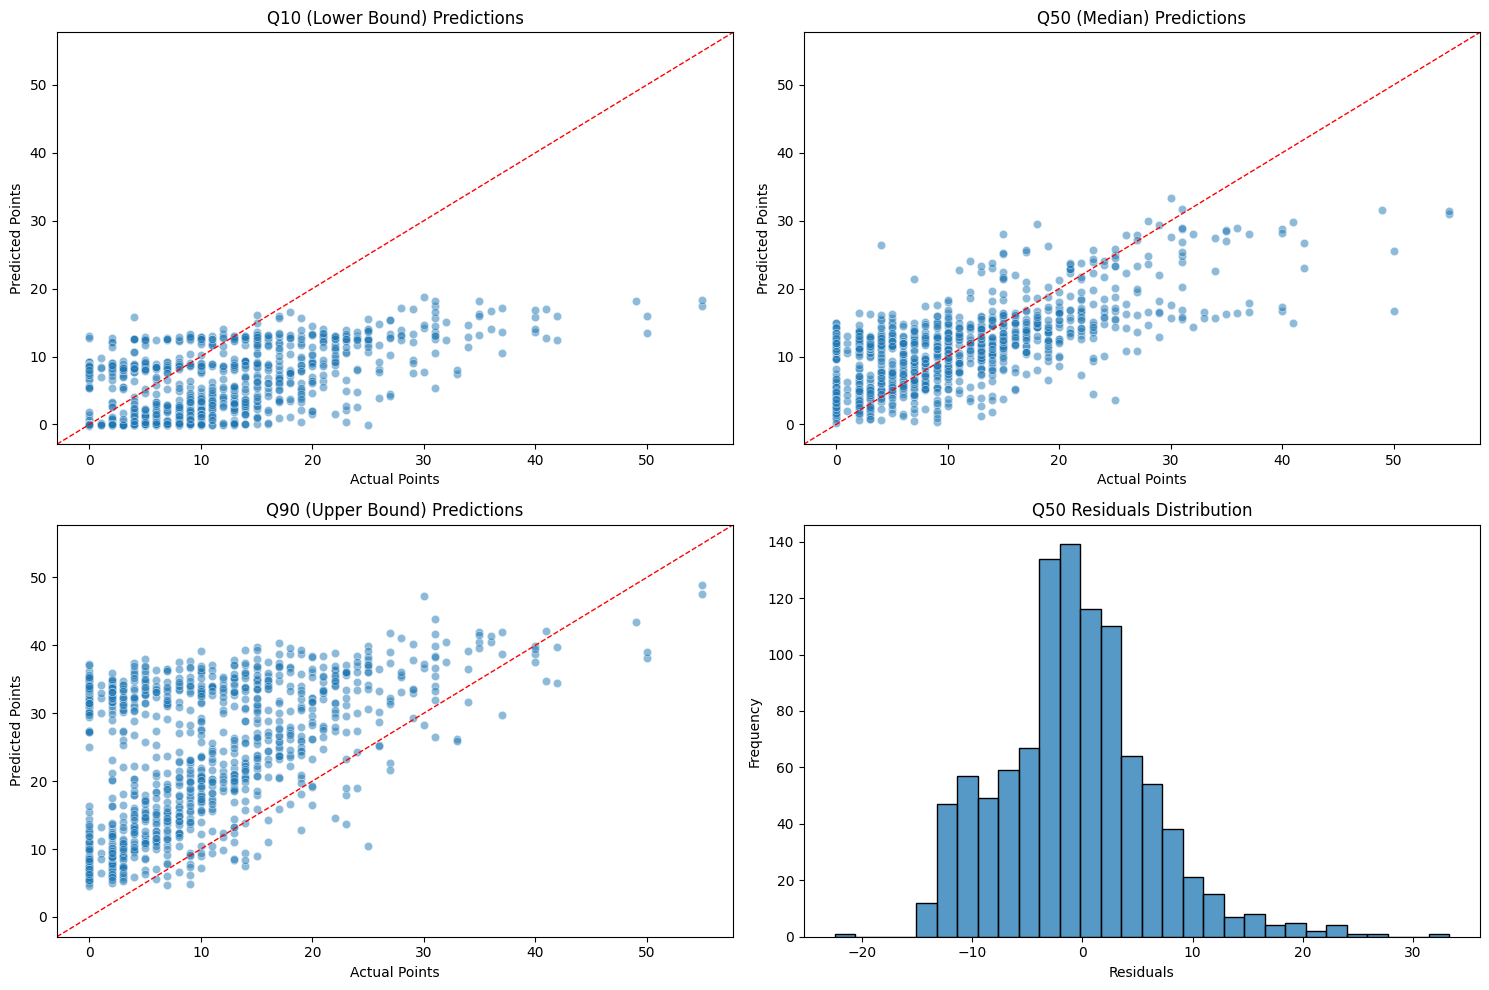

In [36]:
# Enhanced quantile prediction plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Q10 predictions
sns.scatterplot(x='actual', y='pred_q10', data=residuals_df, alpha=0.5, ax=axes[0,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_title('Q10 (Lower Bound) Predictions')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Q50 predictions  
sns.scatterplot(x='actual', y='pred_q50', data=residuals_df, alpha=0.5, ax=axes[0,1])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_title('Q50 (Median) Predictions')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Q90 predictions
sns.scatterplot(x='actual', y='pred_q90', data=residuals_df, alpha=0.5, ax=axes[1,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[1,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[1,0].set_title('Q90 (Upper Bound) Predictions')
axes[1,0].set_xlabel('Actual Points')
axes[1,0].set_ylabel('Predicted Points')

# Residuals distribution
sns.histplot(residuals_df['residual_q50'], bins=30, ax=axes[1,1])
axes[1,1].set_title('Q50 Residuals Distribution')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

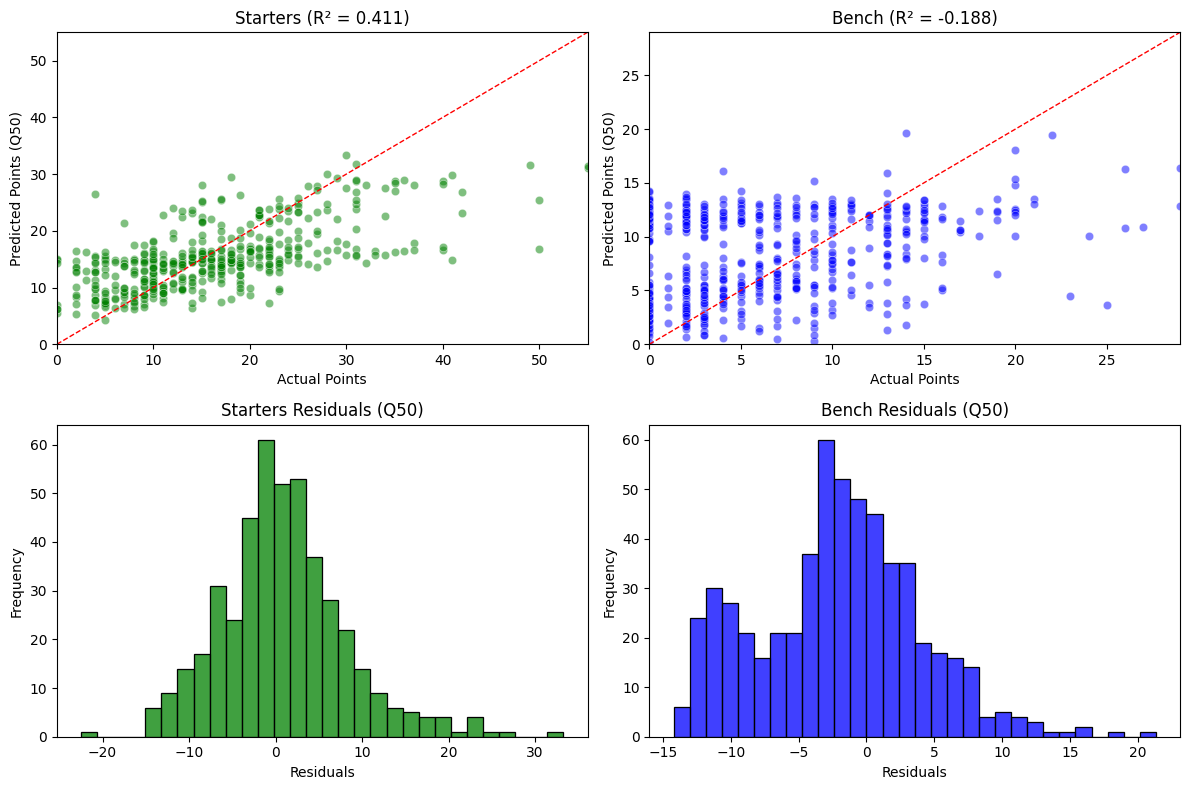

In [37]:
# Get quantile residuals first
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')

# Split by starting status
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

# Calculate R² for Q50 (median) predictions
from sklearn.metrics import r2_score
starters_r2 = r2_score(starters['actual'], starters['pred_q50'])
bench_r2 = r2_score(bench['actual'], bench['pred_q50'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

# Starters scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['pred_q50'].min())
maxVal = max(starters['actual'].max(), starters['pred_q50'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points (Q50)')

# Bench scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['pred_q50'].min())
maxVal = max(bench['actual'].max(), bench['pred_q50'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points (Q50)')

# Starters residuals
sns.histplot(starters['residual_q50'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals (Q50)')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

# Bench residuals
sns.histplot(bench['residual_q50'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals (Q50)')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

In [28]:
joblib.dump(xgbModels['q10'], 'SAVED_MODELS/xgb_q10_modelv2.pkl')
joblib.dump(xgbModels['q50'], 'SAVED_MODELS/xgb_q50_modelv2.pkl')
joblib.dump(xgbModels['q90'], 'SAVED_MODELS/xgb_q90_modelv2.pkl')
joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']

In [8]:
joblib.dump(xgbModels['q10'], 'SAVED_MODELS/xgb_q10_current.pkl')
joblib.dump(xgbModels['q50'], 'SAVED_MODELS/xgb_q50_current.pkl')
joblib.dump(xgbModels['q90'], 'SAVED_MODELS/xgb_q90_current.pkl')
joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']